# **데이터 불러오기 및 정리**

In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import io
import missingno as msno
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [103]:
from google.colab import files
uploaded = files.upload()

Saving vgames2.csv to vgames2 (2).csv


In [104]:
df = pd.read_csv(io.StringIO(uploaded['vgames2.csv'].decode('utf-8')))
df = df.iloc[:,1:]

df.dtypes

Name            object
Platform        object
Year           float64
Genre           object
Publisher       object
NA_Sales        object
EU_Sales        object
JP_Sales        object
Other_Sales     object
dtype: object

In [105]:
# missing values percentage each columns
for col in df.columns:
  msg = "col: {:<15}\t percentage of nan : {:.2f}%\t total : {}".format(col, 100*(df[col].isna().sum() / df[col].shape[0]), df.shape[0])
  print(msg)

col: Name           	 percentage of nan : 0.00%	 total : 16598
col: Platform       	 percentage of nan : 0.00%	 total : 16598
col: Year           	 percentage of nan : 1.63%	 total : 16598
col: Genre          	 percentage of nan : 0.30%	 total : 16598
col: Publisher      	 percentage of nan : 0.35%	 total : 16598
col: NA_Sales       	 percentage of nan : 0.00%	 total : 16598
col: EU_Sales       	 percentage of nan : 0.00%	 total : 16598
col: JP_Sales       	 percentage of nan : 0.00%	 total : 16598
col: Other_Sales    	 percentage of nan : 0.00%	 total : 16598


In [106]:
# missing cols : Year, Genre, Publisher 

def flatFormat(year):
  if(year<0):
    return year
  if(year<=21):
    year += 2000
  elif(year<100):
    year += 1900

  return year

# year to standard form, missing value to -1
df["Year"] = df["Year"].fillna(-1).apply(lambda x: int(x)).apply(flatFormat)
# genre, missing value to Unknown
df["Genre"] = df["Genre"].fillna("Unknown")
# publisher, missing value to "-" / Unknown 이라는 값을 갖는 데이터들이 raw data에 이미 존재하고 있었음
df["Publisher"] = df["Publisher"].fillna("Unknown")

In [107]:
# Sales type string to float .2f, scale standardation
def flat_num(num):
  if "K" in num:
    num = round(float(num.replace("K",""))/1000, 2)
  elif "M" in num:
    num = float(num.replace("M",""))
  else:
    num = float(num)
  
  return num

df["NA_Sales"] = df['NA_Sales'].apply(flat_num)
df["EU_Sales"] = df['EU_Sales'].apply(flat_num)
df["JP_Sales"] = df['JP_Sales'].apply(flat_num)
df["Other_Sales"] = df['Other_Sales'].apply(flat_num)

In [108]:
# Platform name re-name as known name
dictPlatform = {"DS":"NintendoDS", "Wii":"NintendoWii", "PSP":"PSP", "PS3":"PlayStation3", "PC":"PC","PS":"PlayStation","GBA":"GameBoyAdvance","PS4":"PlayStation4","PS2":"PlayStation2",
                "XB":"XBox","X360":"XBox360","GC":"NintendoGameCube", "3DS":"Nintendo3DS", "2600":"Atari2600","SAT":"SegaSaturn", "GB":"GameBoy","NES":"NintendoEntertainmentSystem",
                "DC":"DreamCast","N64":"Nintendo64","XOne":"XboxOne","SNES":"SuperNintendoEntertainmentSystem","WiiU":"NintendoWiiU","PSV":"PlayStationVita","GEN":"SegaGenesis",
                "SCD":"SegaCD","WS":"WonderSwan","NG":"NeoGeo","TG16":"TurboGrafx16","3DO":"3DO","GG":"SegaGameGear", "PCFX":"PCFX"}      

def platformName(platform):
  platform = dictPlatform[platform]
  return platform

df["Platform"] = df["Platform"].apply(platformName)

In [109]:
# 이상까지 df 만들기. df는 꼭 변형하지 않기

데이터를 보면 게임별로 멀티 플랫폼인 경우가 존재한다 게임별로 몇번 중복되는가를 새로운 피처로 만들어 데이터를 df_merge_repeat으로 만든다.

In [110]:
# There are repeated game (NOT each game has one data)
repeatName = df["Name"].value_counts()
df_repeat = pd.DataFrame(repeatName).reset_index()
df_repeat.columns=["Name","RepeatedCounts"]

df_copy = df.copy()
df_merge_repeat = pd.merge(left=df_copy, right=df_repeat, on="Name", left_index=True, how="inner").reset_index(drop=True)
print(df_merge_repeat.shape)
df_merge_repeat.head()

(16598, 10)


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,RepeatedCounts
0,Candace Kane's Candy Factory,NintendoDS,2008,Action,Destineer,0.04,0.0,0.00,0.00,2
1,Candace Kane's Candy Factory,NintendoWii,2008,Action,Destineer,0.14,0.0,0.00,0.01,2
2,The Munchables,NintendoWii,2009,Action,Namco Bandai Games,0.17,0.0,0.00,0.01,1
3,Otome wa Oanesama Boku ni Koi Shiteru Portable,PSP,2010,Adventure,Alchemist,0.00,0.0,0.02,0.00,1
4,Deal or No Deal: Special Edition,NintendoDS,2010,Misc,Zoo Games,0.04,0.0,0.00,0.00,1


In [111]:
df_merge_repeat[df_merge_repeat["Genre"] == "Unknown"].shape

(50, 10)

In [112]:
df_merge_repeat[df_merge_repeat["Publisher"] == "Unknown"].shape

(261, 10)

missing values genre 보강

In [113]:
# missing values in genre 보강 
df_genre_unknown = df_merge_repeat[(df_merge_repeat["Genre"]=="Unknown") & (df_merge_repeat["RepeatedCounts"]>=2)]
print(df_genre_unknown.shape)

alist=[]
for game in df_genre_unknown["Name"]:
  series = df_merge_repeat[df_merge_repeat["Name"]==game]["Genre"]
  for genre in series.unique(): #series.unique 의 길이가 2인 것을 확인했음,
    if(genre != "Unknown"):
      alist.append(genre)
      break

# missing values를 df_merge_repeat에서 찾아서 보강
df_genre_unknown["Genre"] = alist

# 보강한 missing values를 df_merge_repeat에 반영
for idx in df_genre_unknown.index:
  df_merge_repeat.loc[idx] = df_genre_unknown.loc[idx]

(20, 10)


missing values publisher 보강

In [114]:
# missing values in Publisher 보강
df_publisher_unknown = df_merge_repeat[(df_merge_repeat["Publisher"]=="Unknown") & (df_merge_repeat["RepeatedCounts"]>=2)]

print(len(df_publisher_unknown["Name"].unique()), df_publisher_unknown.shape[0]) # 중복된 게임이 존재하며 repeated counts == 게임의 개수 라면 해당 게임에 대해서는 결측치 보강을 할 수 없다. 

73 89


In [115]:
df_repeat_all = pd.DataFrame(df_publisher_unknown["Name"].value_counts()).reset_index()
df_repeat_all.columns = ["Name","Count"]

df_repeat_all = pd.merge(left=df_publisher_unknown, right=df_repeat_all, on="Name", right_index=True, how="inner")
df_publisher_unknown = df_repeat_all[~(df_repeat_all["RepeatedCounts"] == df_repeat_all["Count"])] # 중복된 게임이 존재하며 repeated counts == 게임의 개수 인 게임 제외
df_publisher_unknown

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,RepeatedCounts,Count
57,World of Tanks,XBox360,-1,Shooter,Unknown,0.00,0.03,0.00,0.00,2,1
170,Teenage Mutant Ninja Turtles,GameBoyAdvance,2003,Action,Unknown,0.67,0.25,0.00,0.02,6,1
391,Madden NFL 07,PSP,-1,Sports,Unknown,0.77,0.03,0.00,0.04,9,1
747,Majesty 2: The Fantasy Kingdom Sim,XBox360,-1,Simulation,Unknown,0.03,0.00,0.00,0.00,2,1
796,Gummy Bears Mini Golf,NintendoWii,2010,Sports,Unknown,0.04,0.00,0.00,0.00,2,1
...,...,...,...,...,...,...,...,...,...,...,...
13197,Tom and Jerry in War of the Whiskers,XBox,-1,Fighting,Unknown,0.02,0.01,0.00,0.00,3,1
13262,Time Travelers,Nintendo3DS,2012,Adventure,Unknown,0.00,0.00,0.04,0.00,3,1
13674,Godzilla: Destroy All Monsters Melee,XBox,-1,Fighting,Unknown,0.09,0.03,0.00,0.00,2,1
13678,Rhythm Heaven,NintendoWii,-1,Misc,Unknown,0.13,0.00,0.77,0.01,2,1


In [116]:
# Publisher와 Year를 동시에 모르면 Publisher를 추측할 방법이 없으므로 제외한다. year를 기준으로 찾는 이유 : 같은 해에는 여러 퍼블리셔를 상식적으로 계약하지 않을 것이다.
df_publisher_unknown = df_publisher_unknown[~(df_publisher_unknown["Year"]== -1)]
df_publisher_unknown.shape

(16, 11)

In [117]:
# df_merge_repeat 에서 해당 게임을 찾되 같은 연도에서 publisher를 가져온다. 같은 해에는 여러 퍼블리셔를 상식적으로 계약하지 않을 것이다.
# publish 와 year 중 publish를 먼저 보강하는 이유는 year를 알면 publisher를 특정할 수 있지만 publisher가 같다고해서 year가 같다는 보장이 없기 때문이다. year는 독립.
alist=[]
for game, years in np.array(df_publisher_unknown[["Name","Year"]]):
  temp=0
  dataf = df_merge_repeat[df_merge_repeat["Name"]==game][["Publisher","Year"]]
  for publisher, year in np.array(dataf):
    if((publisher != "Unknown") & (year == years)):
      alist.append(publisher)
      temp=1
      break
  if(temp != 1):
    alist.append("Unknown")

# missing values를 df_merge_repeat에서 찾아서 보강
df_publisher_unknown["Publisher"] = alist
df_publisher_unknown

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,RepeatedCounts,Count
170,Teenage Mutant Ninja Turtles,GameBoyAdvance,2003,Action,Konami Digital Entertainment,0.67,0.25,0.00,0.02,6,1
796,Gummy Bears Mini Golf,NintendoWii,2010,Sports,Storm City Games,0.04,0.00,0.00,0.00,2,1
1063,Terraria,PC,2011,Action,Unknown,0.00,0.13,0.00,0.02,8,1
1241,Blitz: The League,PlayStation2,2005,Sports,Unknown,0.74,0.03,0.00,0.12,3,1
2065,Disney Sports Football,GameBoyAdvance,2002,Sports,Konami Digital Entertainment,0.01,0.01,0.00,0.00,2,1
2179,Bound By Flame,XBox360,2014,Role-Playing,Focus Home Interactive,0.00,0.01,0.00,0.00,2,1
2912,Final Fantasy Type-0,PSP,2011,Role-Playing,Unknown,0.00,0.00,0.81,0.00,3,1
3116,Test Drive: Ferrari Legends,PlayStation3,2012,Racing,Atari,0.04,0.00,0.00,0.00,2,1
3800,Bookworm,GameBoyAdvance,2004,Puzzle,Unknown,0.02,0.01,0.00,0.00,2,1
6366,Guilty Gear XX Accent Core,PlayStation2,2007,Fighting,505 Games,0.00,0.00,0.04,0.00,2,1


In [118]:
# 보강한 missing values를 df_merge_repeat에 반영
for idx in df_publisher_unknown.index:
  df_merge_repeat.loc[idx] = df_publisher_unknown.loc[idx]

In [119]:
total = df_merge_repeat.iloc[:,5:9].sum(1)
df_merge_repeat.insert(loc=9, column="Total_Sales", value = total)

**결측치 보강 끝** 아래 : 보강 결과 확인

In [120]:
df_merge_repeat["Genre"].value_counts()

Action          3309
Sports          2346
Misc            1735
Role-Playing    1483
Shooter         1310
Adventure       1282
Racing          1246
Platform         885
Simulation       866
Fighting         848
Strategy         680
Puzzle           578
Unknown           30
Name: Genre, dtype: int64

In [121]:
test = pd.DataFrame(df_merge_repeat["Publisher"].value_counts())
test.loc["Unknown"]

Publisher    251
Name: Unknown, dtype: int64

In [122]:
print("보강 결과 : genre unknown 50 -> 30, publisher unknown 261 -> 251 로 reduction 됨")

보강 결과 : genre unknown 50 -> 30, publisher unknown 261 -> 251 로 reduction 됨


In [176]:
df_merge_repeat

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales,RepeatedCounts
0,Candace Kane's Candy Factory,NintendoDS,2008,Action,Destineer,0.04,0.0,0.00,0.00,0.04,2
1,Candace Kane's Candy Factory,NintendoWii,2008,Action,Destineer,0.14,0.0,0.00,0.01,0.15,2
2,The Munchables,NintendoWii,2009,Action,Namco Bandai Games,0.17,0.0,0.00,0.01,0.18,1
3,Otome wa Oanesama Boku ni Koi Shiteru Portable,PSP,2010,Adventure,Alchemist,0.00,0.0,0.02,0.00,0.02,1
4,Deal or No Deal: Special Edition,NintendoDS,2010,Misc,Zoo Games,0.04,0.0,0.00,0.00,0.04,1
...,...,...,...,...,...,...,...,...,...,...,...
16593,Jikkyou Powerful Pro Yakyuu 2000 Ketteiban,PlayStation,2000,Sports,Konami Digital Entertainment,0.00,0.0,0.08,0.01,0.09,1
16594,Namco Soccer Prime Goal,PlayStation,1995,Sports,Sony Computer Entertainment,0.00,0.0,0.12,0.01,0.13,1
16595,White Album: Tsuzurareru Fuyu no Omoide,PlayStation3,2010,Adventure,Aqua Plus,0.00,0.0,0.05,0.00,0.05,1
16596,Minna no Chizu 2,PSP,2007,Misc,Zenrin,0.00,0.0,0.02,0.00,0.02,1


# **지역에 따라서 선호하는 게임의 장르가 다를까?**

In [123]:
df_merge_repeat.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales,RepeatedCounts
0,Candace Kane's Candy Factory,NintendoDS,2008,Action,Destineer,0.04,0.0,0.00,0.00,0.04,2
1,Candace Kane's Candy Factory,NintendoWii,2008,Action,Destineer,0.14,0.0,0.00,0.01,0.15,2
2,The Munchables,NintendoWii,2009,Action,Namco Bandai Games,0.17,0.0,0.00,0.01,0.18,1
3,Otome wa Oanesama Boku ni Koi Shiteru Portable,PSP,2010,Adventure,Alchemist,0.00,0.0,0.02,0.00,0.02,1
4,Deal or No Deal: Special Edition,NintendoDS,2010,Misc,Zoo Games,0.04,0.0,0.00,0.00,0.04,1


In [124]:
# 한 게임이 멀티 장르로 분류된 사례
df_test = df_merge_repeat.copy()

df_test[(df_test["Name"]=="Steins;Gate: Hiyoku Renri no Darling") | (df_test["Name"]=="Syndicate") |(df_test["Name"]=="Culdcept") |
        (df_test["Name"]=="Little Busters! Converted Edition")]

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales,RepeatedCounts
262,Steins;Gate: Hiyoku Renri no Darling,PlayStation3,2012,Adventure,5pb,0.00,0.00,0.02,0.00,0.02,3
263,Steins;Gate: Hiyoku Renri no Darling,XBox360,2011,Adventure,5pb,0.00,0.00,0.08,0.00,0.08,3
264,Steins;Gate: Hiyoku Renri no Darling,PSP,2012,Action,5pb,0.00,0.00,0.06,0.00,0.06,3
647,Syndicate,XBox360,2012,Shooter,Electronic Arts,0.10,0.06,0.00,0.02,0.18,3
648,Syndicate,PC,1992,Strategy,Electronic Arts,0.00,0.05,0.00,0.01,0.06,3
649,Syndicate,PlayStation3,2012,Shooter,EA Games,0.07,0.06,0.00,0.02,0.15,3
5099,Culdcept,PlayStation2,2002,Strategy,Sega,0.01,0.01,0.00,0.00,0.02,2
5100,Culdcept,Nintendo3DS,2012,Misc,Nintendo,0.00,0.00,0.16,0.00,0.16,2
10423,Little Busters! Converted Edition,PSP,2010,Adventure,Prototype,0.00,0.00,0.04,0.00,0.04,3
10424,Little Busters! Converted Edition,PlayStation2,2009,Adventure,Prototype,0.00,0.00,0.05,0.00,0.05,3


In [125]:
# 게임 장르의 선호를 보는 것이기 때문에 데이터를 게임과 장르로 묶어야 하며 한 게임이 다른 장르로 집계된 게임은 4가지가 있음을 알게 되었다.(위에서)
df_genre_region = df_merge_repeat.copy().groupby(["Name","Genre"])[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum().reset_index().drop("Name", axis=1)

In [126]:
df_genre_region = df_genre_region[~(df_genre_region["Genre"]=="Unknown")]

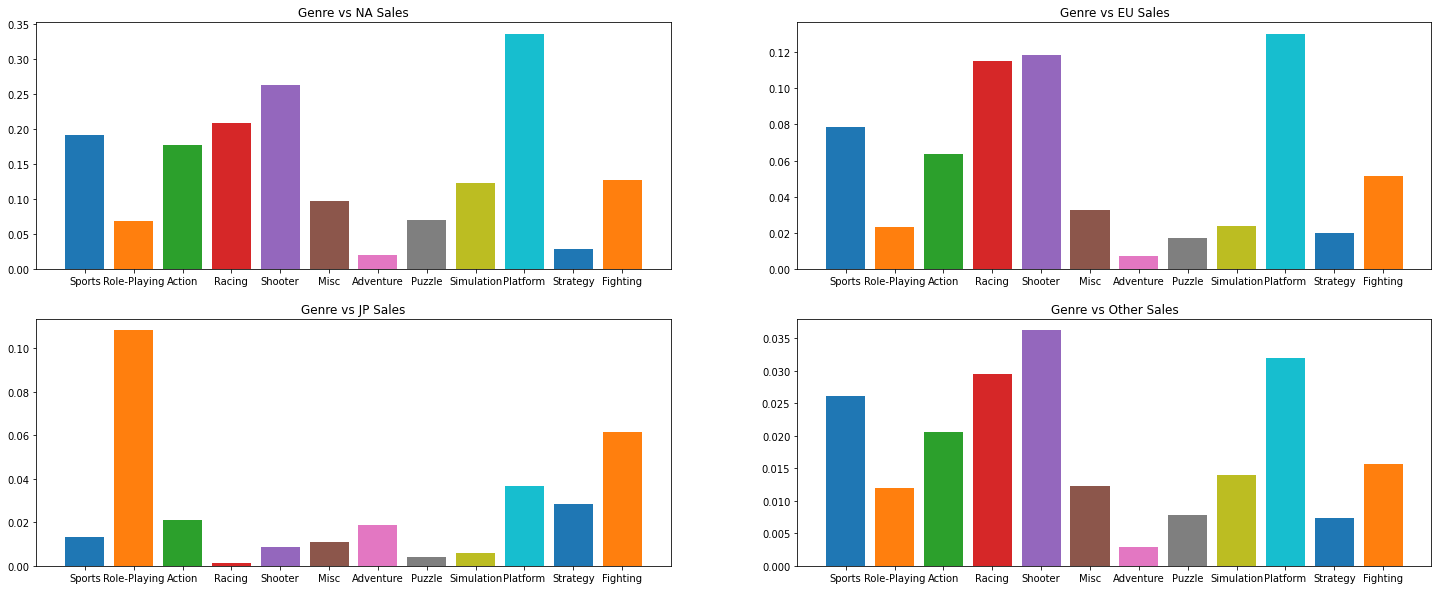

In [127]:
# 일반적인 장르에 따른 결과를 보기 위해 세일즈 순위대로 나열했을 때, boxplot outlier 를 계산해서 사용한다. +-IQR*1.5
start = df_genre_region.groupby("Genre").quantile(0.25)
end = df_genre_region.groupby("Genre").quantile(0.75)
min = pd.DataFrame(np.array(start)-1.5*(np.array(end)-np.array(start)), index=start.index, columns=start.columns)
max = pd.DataFrame(np.array(end)+1.5*(np.array(end)-np.array(start)), index=start.index, columns=start.columns)

f, ax = plt.subplots(2,2, figsize=(25,10))

# plotting genre vs sales 
alist = [(0,0),(0,1),(1,0),(1,1)]
k=0
for region in df_genre_region.columns[1:]:
  i,j = alist[k]
  for genre in df_genre_region["Genre"].unique():
    temp_df = df_genre_region[df_genre_region["Genre"] == genre]
    data = temp_df[region][temp_df[region].gt(min.loc[genre, region]) & temp_df[region].lt(max.loc[genre, region])].mean()
    ax[i][j].bar(x=genre, height=data, )
    ax[i][j].set_title("Genre vs {}".format(region.replace("_"," ")))
  k+=1

In [128]:
def mod_df_ttest(region, genre):
  temp_df = df_genre_region[df_genre_region["Genre"] == genre]
  data = temp_df[region][temp_df[region].gt(min.loc[genre, region]) & temp_df[region].lt(max.loc[genre, region])]
  return data

# NA Sales 장르 탑 2 ttest 비교해서 통계적으로 같은가 비교
p_NA = stats.ttest_ind(mod_df_ttest("NA_Sales", "Platform"), mod_df_ttest("NA_Sales","Shooter")).pvalue

# EU Sales 장르 탑 2 ttest 비교해서 통계적으로 같은가 비교
p_EU = stats.ttest_ind(mod_df_ttest("EU_Sales", "Platform"), mod_df_ttest("EU_Sales","Shooter")).pvalue

# JP Sales 장르 탑 2 ttest 비교해서 통계적으로 같은가 비교
p_JP = stats.ttest_ind(mod_df_ttest("JP_Sales", "Role-Playing"), mod_df_ttest("JP_Sales","Fighting")).pvalue

# Other Sales 장르 탑 2 ttest 비교해서 통계적으로 같은가 비교
p_Other = stats.ttest_ind(mod_df_ttest("Other_Sales", "Platform"), mod_df_ttest("Other_Sales","Shooter")).pvalue

print("pvalue of NA:{}, EU:{}, JP:{}, Other:{}".format(p_NA, p_EU, p_JP, p_Other))

pvalue of NA:0.00038016853632793644, EU:0.25704305647282344, JP:1.800143074094756e-13, Other:0.1288163640735331


In [129]:
# t test 결과 EU, Other ANOVA test
p_anova_EU = stats.f_oneway(mod_df_ttest("EU_Sales", "Platform"), mod_df_ttest("EU_Sales","Shooter"), mod_df_ttest("EU_Sales","Racing")).pvalue
p_anova_EU

p_anova_Other = stats.f_oneway(mod_df_ttest("Other_Sales", "Platform"), mod_df_ttest("Other_Sales","Shooter"), mod_df_ttest("EU_Sales","Racing")).pvalue
p_anova_Other

print("Anova test result : EU : {}, Other : {}".format(p_anova_EU, p_anova_Other))

Anova test result : EU : 0.2766236957929747, Other : 2.0176556537028667e-60


In [130]:
# Other sales : 0.05/3 = 0.0167보다 작은가? 본페르니 사후검정
stats.ttest_ind(mod_df_ttest("Other_Sales", "Racing"), mod_df_ttest("Other_Sales","Shooter")).pvalue 

0.0075336073706432655

위의 가설검정 결과 

NA : Platform, JP : Role-Playing 으로 하나 씩의 장르만이 유의미한 평균 차이를 보이며 기록되었고 EU와 Other의 경우 세 그룹이 비슷한 평균을 가지게 되어 추가로 ANOVA 테스트를 진행했다.

EU의 ANOVA 테스트 결과 선두 세 장르가 통계적으로 유의하지 않음을 알 수 있었으므로 EU : Platform, Shooter, Racing 장르를 선호하는 것으로 결론 지을 수 있다.

Other의 경우 Shooter = Platform, Platform = Racing, Shooter != Platform 이라는 결과를 얻었다. 

다만 Other의 경우 여러 나라가 섞여 있으므로 지역에 따라 선호하는 게임을 분석하는 이번 장에서 무시해도 좋다.

결론 : 미국과 유럽은 비슷한 경향을 보이는 와중에 공통적으로 Platform 장르를 선호하며 일본은 독보적으로 Role-Playing 장르를 선호한다.

# **연도별 게임의 트렌드가 있을까?**

## **연도별 게임 트렌드 조사용 데이터 구축**

In [131]:
df_year = df_merge_repeat.copy()
df_year = df_year[~(df_year["Year"]==-1)] # missing value -1 delete

In [132]:
df_year_test = pd.DataFrame(df_year["Year"].value_counts()).reset_index()
df_year_test.columns=["Year", "Counts"]

df_year_test.sort_values(by="Counts").head()

,Year,Counts
38,2020,1
37,2017,3
36,1980,9
35,1984,14
34,1985,14


In [133]:
# 데이터 수가 현저히 부족한 년도의 게임을 직접 조사한다.
df_year[(df_year["Year"]==2017) | (df_year["Year"]==2020)]
# imagine makeup artist 게임은 2020보다 훨씬 오래전 출시된 게임이다. 잘못된 데이터이므로 삭제한다.
# Brothers Conflict: Precious Baby 게임은 2016년도 작이다.
# Phantasy Star Online 2 Episode 4: Deluxe Package 2016년도 작이다.

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales,RepeatedCounts
8144,Brothers Conflict: Precious Baby,PlayStationVita,2017,Action,Idea Factory,0.00,0.0,0.01,0.00,0.01,1
9840,Imagine: Makeup Artist,NintendoDS,2020,Simulation,Ubisoft,0.27,0.0,0.00,0.02,0.29,1
12593,Phantasy Star Online 2 Episode 4: Deluxe Package,PlayStation4,2017,Role-Playing,Sega,0.00,0.0,0.03,0.00,0.03,2
12594,Phantasy Star Online 2 Episode 4: Deluxe Package,PlayStationVita,2017,Role-Playing,Sega,0.00,0.0,0.01,0.00,0.01,2


In [134]:
# 2020, 2017년 게임을 배제하여 데이터를 재구성한다.
df_year = df_year[~((df_year["Year"]==2017) | (df_year["Year"]==2020))]

## **연도별 출고량의 변화**

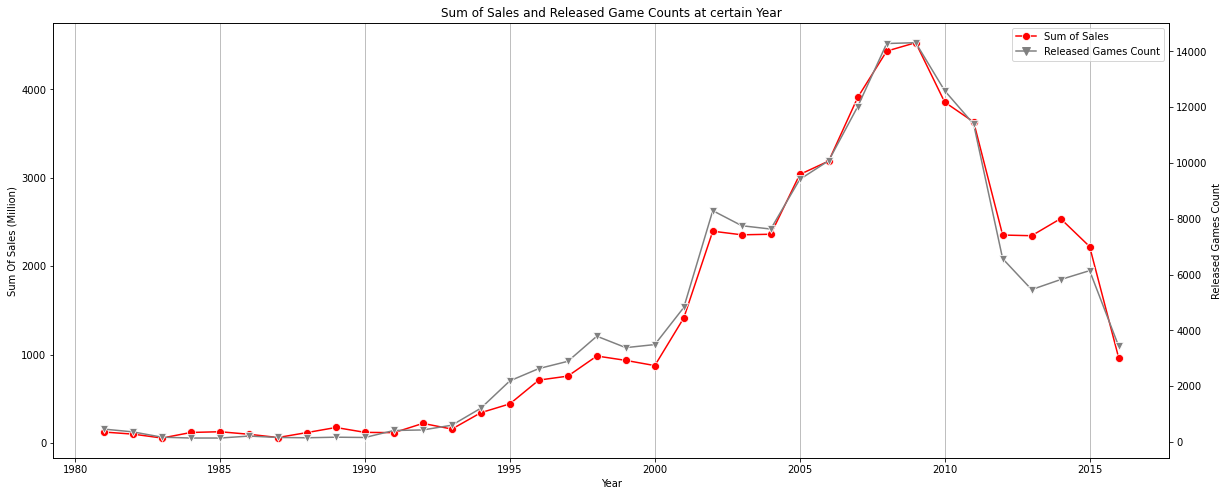

In [135]:
df_sum = df_year.groupby("Year").sum()[1:]
df_count = df_year.groupby("Year").count()[1:]

df_sum["Sum"] = df_sum.sum(1)
df_sum = df_sum.reset_index()

df_count["SumOfCount"] = df_count.sum(1)
df_count = df_count.reset_index()

f, ax = plt.subplots(1,1,figsize=(20,8))

plt.title("Sum of Sales and Released Game Counts at certain Year")
plt.grid(True, axis="x")

ax2 = ax.twinx()
sns.lineplot(x="Year", y="Sum", data=df_sum, ax=ax, color="r", label="Sum of Sales", marker="o", markersize=8)
sns.lineplot(x="Year", y="SumOfCount", data=df_count, ax=ax2, color="gray", marker="v", markersize=8)
ax.plot(np.nan, "gray", label = "Released Games Count", marker="v", markersize=8)
ax.legend(loc=0)

ax.set_ylabel("Sum Of Sales (Million)")
ax2.set_ylabel("Released Games Count")

plt.show()

## **연도별 플랫폼의 변화**

In [136]:
df_year_platform = pd.crosstab(df_year["Year"], df_year["Platform"])
df_year_platform

# 연도별 출시 플랫폼의 빈도수 변화
_,pvalue,_,_ = stats.chi2_contingency(df_year_platform, correction=True)

pvalue
# pvalue = 0 이라는 말 : 연도별 플랫폼의 변화가 존재한다. 기대되는 빈도수와는 다른 양상을 가진다는 의미 : 시간이 지남에 따라 플랫폼의 변화가 생겼다는 의미

0.0

In [137]:
# 연도별 선호 플랫폼 top 1시각화 해보자

df_year_platform["TopPlatform"] = df_year_platform.idxmax(1)
df_year_platform["TopCount"] = df_year_platform.max(1)
df_year_platform["TopPlatformShare"] = df_year_platform.max(1) / df_year_platform.iloc[:,:-1].sum(1)

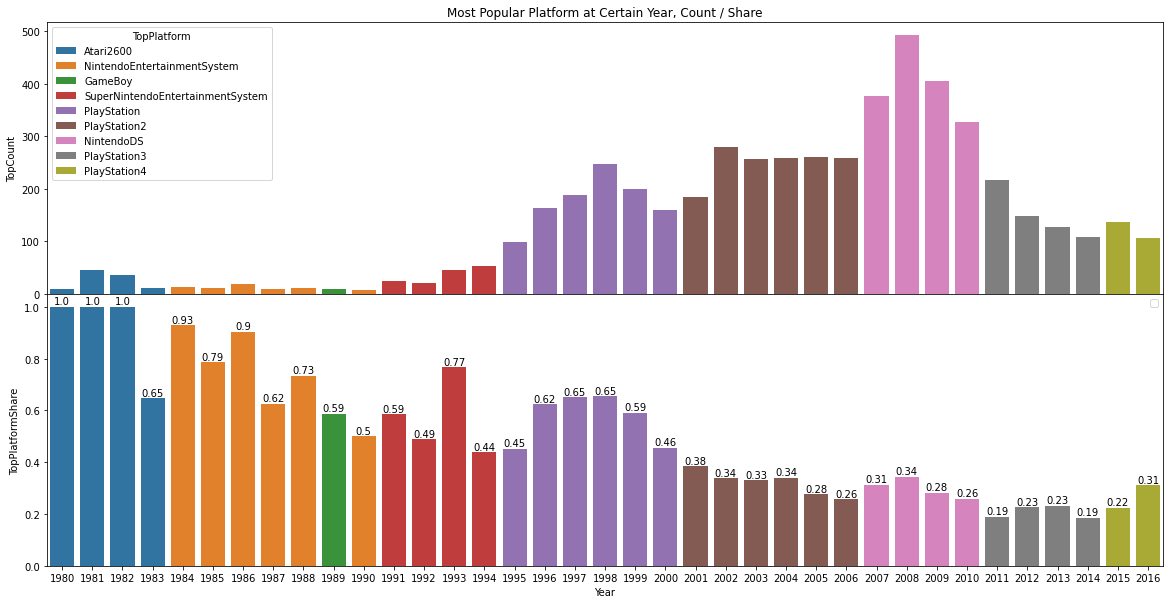

In [138]:
f, ax = plt.subplots(2,1, figsize=(20,10), sharex=True, gridspec_kw = {'wspace':0, 'hspace':0})
sns.barplot(x="Year", y="TopCount", hue="TopPlatform", data=df_year_platform.reset_index(), dodge=False, ax=ax[0])
g = sns.barplot(x="Year", y="TopPlatformShare", hue="TopPlatform", data=df_year_platform.reset_index(), dodge=False, ax=ax[1])

for idx, row in df_year_platform.reset_index()[["Year","TopCount", "TopPlatformShare"]].iterrows():
  g.text(row.name, row.TopPlatformShare + 0.01, round(row.TopPlatformShare,2), color="black", ha="center", fontdict=dict(fontsize=10))

ax[0].set_title("Most Popular Platform at Certain Year, Count / Share")
ax[0].set_xlabel("")
ax[1].legend("")
ax[1].set_ylim(auto=True)

plt.show()

## **연도별 출시게임 장르의 변화**

In [139]:
df_year_genre = pd.crosstab(df_year["Year"], df_year["Genre"])
df_year_genre.drop("Unknown", axis=1, inplace=True) # unknown genre delete

_,pvalue,_,_ = stats.chi2_contingency(df_year_genre)
print(pvalue) # 장르의 변화가 존재한다.

0.0


In [140]:
df_year_genre["TopGenre"] = df_year_genre.idxmax(1)
df_year_genre["TopCount"] = df_year_genre.max(1)
df_year_genre["TopGenreShare"] = round(df_year_genre.max(1) / df_year_genre.iloc[:,:-1].sum(1),2)

In [141]:
df_year_genre.head()

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy,TopGenre,TopCount,TopGenreShare
Year,,,,,,,,,,,,,,,
1980,1,0,1,4,0,0,0,0,2,0,1,0,Misc,4,0.44
1981,25,0,0,0,3,2,1,0,10,1,4,0,Action,25,0.54
1982,18,0,0,1,5,3,2,0,5,0,2,0,Action,18,0.50
1983,7,1,0,1,5,1,0,0,1,0,1,0,Action,7,0.41
1984,1,0,0,1,1,3,3,0,3,0,2,0,Puzzle,3,0.21


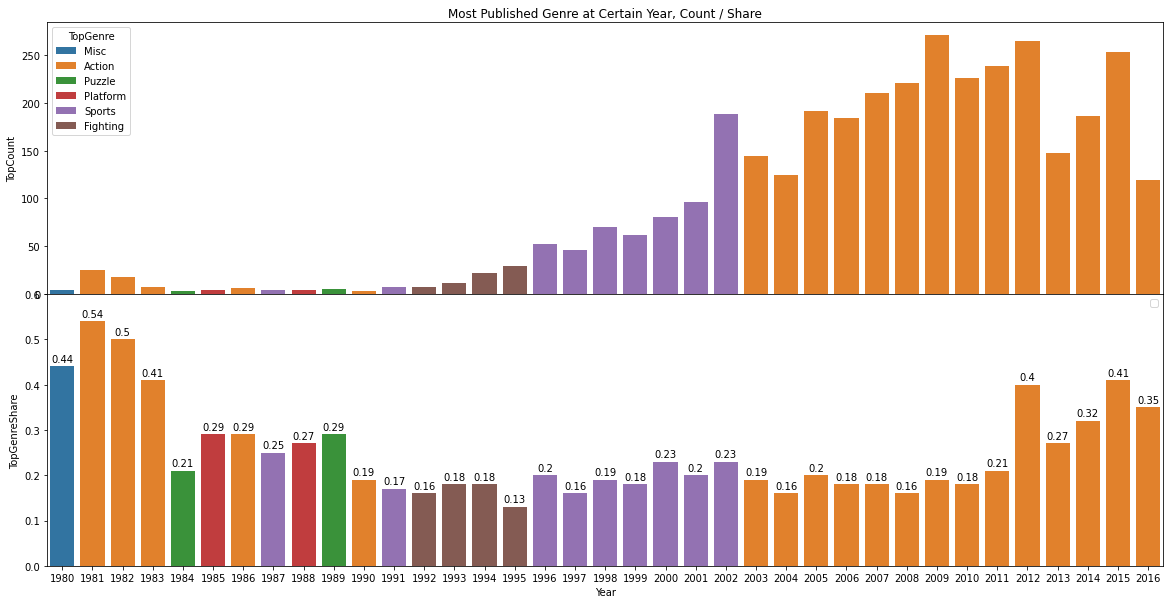

In [142]:
f, ax = plt.subplots(2,1, figsize=(20,10), sharex=True, gridspec_kw = {'wspace':0, 'hspace':0})

sns.barplot(x="Year", y="TopCount", hue="TopGenre", data=df_year_genre.reset_index(), dodge=False, ax=ax[0])
g = sns.barplot(x="Year", y="TopGenreShare", hue="TopGenre", data=df_year_genre.reset_index(), dodge=False, ax=ax[1])

for idx, row in df_year_genre.reset_index()[["Year","TopCount", "TopGenreShare"]].iterrows():
  g.text(row.name, row.TopGenreShare + 0.01, round(row.TopGenreShare,2), color="black", ha="center", fontdict=dict(fontsize=10))

ax[0].set_title("Most Published Genre at Certain Year, Count / Share")
ax[0].set_xlabel("")
ax[1].legend("")
ax[1].set_ylim(top=0.6)

plt.show()

## **연도별 대표 게임 추이 : 게임별 연도별 합산**

In [143]:
adict = {}
df_year_name = df_year.groupby(["Year","Name"]).sum().drop("RepeatedCounts", axis=1)
for year in df_year_name.reset_index().Year.unique():
  mostName = df_year_name.loc[year].idxmax().Total_Sales
  mostSales = df_year_name.loc[year].max().Total_Sales

  adict[year] = [mostName, mostSales]

df_year_TopSalesGame = pd.DataFrame(adict).T.reset_index()
df_year_TopSalesGame.columns=["Year", "Name","Total_Sales"]

In [144]:
df_year_TopSalesGame

,Year,Name,Total_Sales
0,1980,Asteroids,4.31
1,1981,Pitfall!,4.5
2,1982,Pac-Man,7.81
3,1983,Baseball,3.2
4,1984,Duck Hunt,28.31
5,1985,Super Mario Bros.,40.24
6,1986,The Legend of Zelda,6.5
7,1987,Zelda II: The Adventure of Link,4.38
8,1988,Super Mario Bros. 3,17.28
9,1989,Tetris,30.26


# **세일즈에는 어떤 것들이 영향을 줄까**

## **플랫폼이 유명할수록 세일즈가 많아지는가?**

A : 아니오

In [145]:
df_platform_sales = df_year[["Year","Name","Platform","Total_Sales"]].groupby(["Year","Platform","Name"]).sum().drop([1980,1981,1982]).reset_index()

In [146]:
df_platform_sales

,Year,Platform,Name,Total_Sales
0,1983,Atari2600,Crystal Castles,0.77
1,1983,Atari2600,Dolphin,0.29
2,1983,Atari2600,Frogger II: Threeedeep!,0.33
3,1983,Atari2600,Frostbite,0.34
4,1983,Atari2600,Gremlins,0.46
...,...,...,...,...
16226,2016,XboxOne,The Technomancer,0.02
16227,2016,XboxOne,Tom Clancy's The Division,2.00
16228,2016,XboxOne,TrackMania Turbo,0.05
16229,2016,XboxOne,Valentino Rossi: The Game,0.02


In [147]:
df_year_platform_count = pd.crosstab(df_platform_sales["Year"],df_platform_sales["Platform"])

In [148]:
df_year_platform_count.tail()

Platform,3DO,Atari2600,DreamCast,GameBoy,GameBoyAdvance,NeoGeo,Nintendo3DS,Nintendo64,NintendoDS,NintendoEntertainmentSystem,NintendoGameCube,NintendoWii,NintendoWiiU,PC,PCFX,PSP,PlayStation,PlayStation2,PlayStation3,PlayStation4,PlayStationVita,SegaCD,SegaGameGear,SegaGenesis,SegaSaturn,SuperNintendoEntertainmentSystem,TurboGrafx16,WonderSwan,XBox,XBox360,XboxOne
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012,0,0,0,0,0,0,93,0,25,0,0,32,32,61,0,106,0,0,147,0,54,0,0,0,0,0,0,0,0,106,0
2013,0,0,0,0,0,0,91,0,9,0,0,12,42,38,0,54,0,0,127,16,63,0,0,0,0,0,0,0,0,75,19
2014,0,0,0,0,0,0,79,0,1,0,0,6,31,44,0,10,0,0,108,75,102,0,0,0,0,0,0,0,0,65,61
2015,0,0,0,0,0,0,86,0,0,0,0,4,28,50,0,3,0,0,74,137,113,0,0,0,0,0,0,0,0,40,79
2016,0,0,0,0,0,0,35,0,0,0,0,0,10,38,0,0,0,0,32,107,60,0,0,0,0,0,0,0,0,8,54


In [149]:
df_platform_sales["Count"] = [df_year_platform_count.loc[row.Year, row.Platform] for idx, row in df_platform_sales[["Year","Platform"]].iterrows()]

In [150]:
df_platform_sales["Year"].unique()

array([1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016])

In [151]:
alist=[]
for year in df_platform_sales["Year"].unique():
  r, pvalue = stats.pearsonr(df_platform_sales[df_platform_sales["Year"]==year]["Total_Sales"],df_platform_sales[df_platform_sales["Year"]==year]["Count"])
  alist.append([year, r, pvalue])

In [152]:
pd.DataFrame(alist, columns=["year", "r", "pvalue"]).head()

,year,r,pvalue
0,1983,-0.760921,0.000389
1,1984,0.132959,0.650458
2,1985,0.189936,0.515447
3,1986,0.358169,0.110881
4,1987,0.674462,0.004160


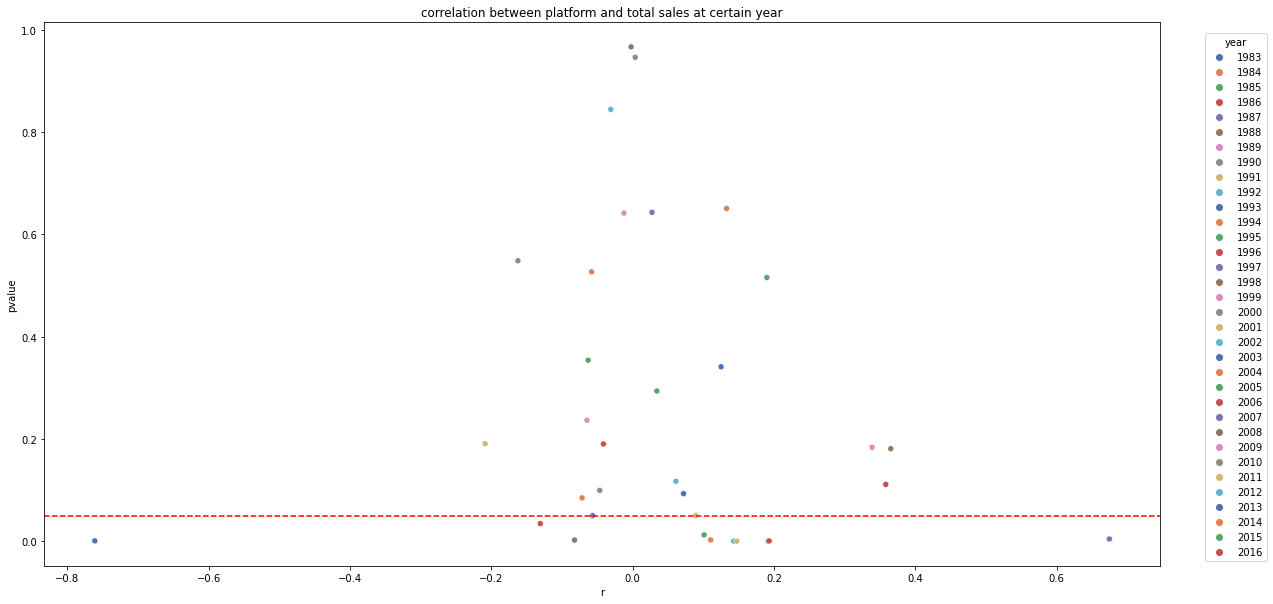

In [153]:
plt.figure(figsize=(20,10))
plt.title("correlation between platform and total sales at certain year")
g = sns.scatterplot(x="r", y="pvalue", hue="year", data = pd.DataFrame(alist, columns=["year", "r", "pvalue"]), palette="deep")
sns.move_legend(g, "lower right", bbox_to_anchor=(1.1,0))
plt.axhline(y=0.05, color="r", ls="--")
plt.show()

In [154]:
d_test = pd.DataFrame(alist, columns=["year", "r", "pvalue"])
len(d_test[d_test["pvalue"]<0.05]) / len(d_test)

0.3235294117647059

## **퍼블리셔가 유명할수록 세일즈가 많아지는가?**

A : 약한 양의 상관관계가 어느정도 있어 보인다.

In [155]:
df_publisher_sales = df_year[["Year","Name","Publisher","Total_Sales"]].groupby(["Year","Publisher","Name"]).sum().reset_index()

In [156]:
df_year_publisher_count = pd.crosstab(df_publisher_sales["Year"],df_publisher_sales["Publisher"])

In [157]:
df_year_publisher_count.head()

Publisher,10TACLE Studios,1C Company,20th Century Fox Video Games,2D Boy,3DO,49Games,505 Games,5pb,7G//AMES,989 Sports,989 Studios,AQ Interactive,ASC Games,ASCII Entertainment,ASCII Media Works,ASK,Abylight,Acclaim Entertainment,Accolade,Ackkstudios,Acquire,Activision,Activision Blizzard,Activision Value,Adeline Software,Aerosoft,Agatsuma Entertainment,Agetec,Aksys Games,Alawar Entertainment,Alchemist,Alternative Software,Altron,Alvion,American Softworks,Angel Studios,Answer Software,Aqua Plus,Aques,Arc System Works,...,Victor Interactive,Video System,Views,Vir2L Studios,Virgin Interactive,Virtual Play Games,Visco,Vivendi Games,Wanadoo,Warashi,Wargaming.net,Warner Bros. Interactive Entertainment,Warp,WayForward Technologies,Westwood Studios,White Park Bay Software,Wizard Video Games,XS Games,Xicat Interactive,Xing Entertainment,Xplosiv,Xseed Games,Yacht Club Games,Yamasa Entertainment,Yeti,Yuke's,Yumedia,Zenrin,Zoo Digital Publishing,Zoo Games,Zushi Games,bitComposer Games,dramatic create,fonfun,iWin,id Software,imageepoch Inc.,inXile Entertainment,"mixi, Inc",responDESIGN
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1980,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1981,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1982,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1983,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1984,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [158]:
df_publisher_sales["Count"] = [df_year_publisher_count.loc[row.Year, row.Publisher] for idx, row in df_publisher_sales[["Year","Publisher"]].iterrows()]

In [159]:
alist=[]
for year in df_publisher_sales["Year"].unique():
  r, pvalue = stats.pearsonr(df_publisher_sales[df_publisher_sales["Year"]==year]["Total_Sales"],df_publisher_sales[df_publisher_sales["Year"]==year]["Count"])
  alist.append([year, r, pvalue])

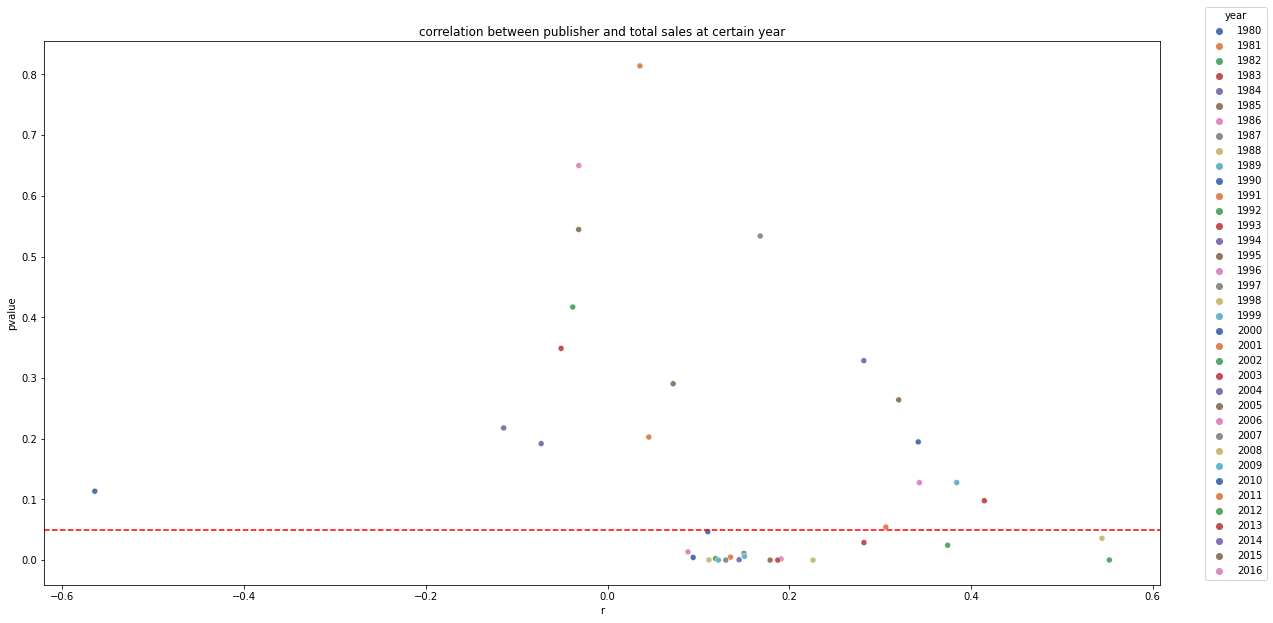

In [160]:
plt.figure(figsize=(20,10))
plt.title("correlation between publisher and total sales at certain year")
g = sns.scatterplot(x="r", y="pvalue", hue="year", data = pd.DataFrame(alist, columns=["year", "r", "pvalue"]), palette="deep")
sns.move_legend(g, "lower right", bbox_to_anchor=(1.1,0))
plt.axhline(y=0.05, color="r", ls="--")
plt.show()

In [161]:
d_test = pd.DataFrame(alist, columns=["year", "r", "pvalue"])
len(d_test[d_test["pvalue"]<0.05]) / len(d_test)

0.5135135135135135

## **탑100 세일즈 게임들의 특징**

In [162]:
df_topSalesName = df_year.groupby("Name").sum().sort_values(by="Total_Sales", ascending=False).reset_index().iloc[:100,:][["Name", "Total_Sales"]]

In [163]:
df_topSalesName = df_topSalesName.reset_index()
df_topSalesName.columns = ["Rank", "Name", "Sum_Total_Sales"]
df_topSalesName

,Rank,Name,Sum_Total_Sales
0,0,Wii Sports,82.74
1,1,Grand Theft Auto V,55.92
2,2,Super Mario Bros.,45.31
3,3,Tetris,35.84
4,4,Mario Kart Wii,35.83
...,...,...,...
95,95,Halo: Reach,9.87
96,96,LEGO Marvel Super Heroes,9.86
97,97,New Super Mario Bros. 2,9.83
98,98,Zumba Fitness,9.79


In [164]:
genreList=[]
for name in df_topSalesName.Name.unique():
  genre = df_merge_repeat[df_merge_repeat["Name"]==name]["Genre"].unique()[0]
  genreList.append(genre)

df_topSalesName["Genre"] = genreList

In [165]:
countList=[]
for name in df_topSalesName.Name.unique():
  count = len(df_merge_repeat[df_merge_repeat["Name"]==name]["Platform"].unique())
  countList.append(count)

df_topSalesName["PlatformCount"] = countList

In [166]:
df_topSalesName['PlatformCount'].mean()

2.93

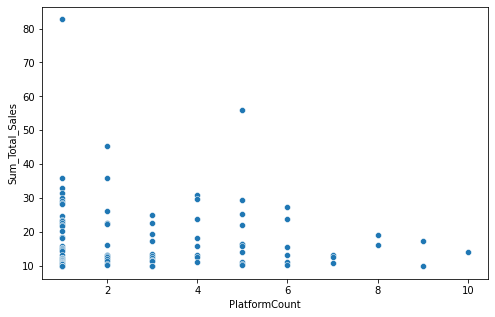

In [167]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="PlatformCount", y="Sum_Total_Sales",data=df_topSalesName)
plt.show()

In [168]:
df_topSalesName_rest = df_year.groupby("Name").sum().sort_values(by="Total_Sales", ascending=False).reset_index().iloc[100:,:][["Name", "Total_Sales"]]

In [169]:
df_topSalesName_rest = df_topSalesName_rest.reset_index()
df_topSalesName_rest.columns = ["Rank", "Name", "Sum_Total_Sales"]
df_topSalesName_rest

,Rank,Name,Sum_Total_Sales
0,100,Final Fantasy VII,9.72
1,101,LEGO Indiana Jones: The Original Adventures,9.69
2,102,Just Dance 2,9.52
3,103,Watch Dogs,9.50
4,104,FIFA Soccer 08,9.50
...,...,...,...
11252,11352,The Sims 4: Luxury Party Stuff,0.01
11253,11353,BattleForge,0.01
11254,11354,Battle Worlds: Kronos,0.01
11255,11355,The Train Giant,0.01


In [170]:
countList=[]
for name in df_topSalesName_rest.Name.unique():
  count = len(df_merge_repeat[df_merge_repeat["Name"]==name]["Platform"].unique())
  countList.append(count)

df_topSalesName_rest["PlatformCount"] = countList

In [171]:
df_topSalesName_rest['PlatformCount'].mean()

1.434662876432442

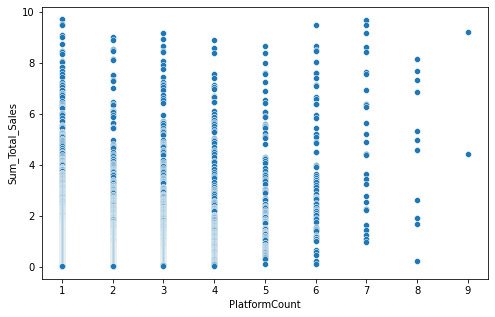

In [172]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="PlatformCount", y="Sum_Total_Sales",data=df_topSalesName_rest)
plt.show()

In [173]:
!pip install scipy --upgrade

In [174]:
tlist=[]
for i in range(1,1001):
  statistic, pvalue = stats.ttest_ind(df_topSalesName["PlatformCount"], df_topSalesName_rest["PlatformCount"].sample(100), alternative="greater")
  tlist.append(pvalue)

t_df = pd.DataFrame(tlist)

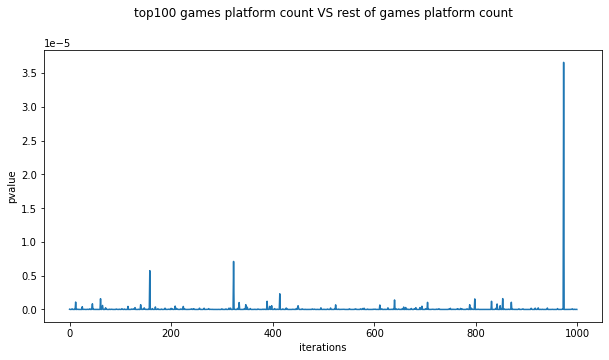

In [175]:
t_df = t_df.reset_index()
t_df.columns=["iterations", "pvalue"]
t_df

plt.figure(figsize=(10,5))
plt.title("top100 games platform count VS rest of games platform count", y=1.1)
sns.lineplot(x="iterations", y="pvalue", data=t_df)
plt.show() # 굉장히 유의함. -> top100과 나머지 게임들의 출시하는 플랫폼의 개수가 통계적으로 다름을 알 수 있다.